In [475]:
import pandas as pd

# Leer el CSV
df_2074 = pd.read_csv(
    "../data/viajeros_pernoctaciones_2074_11_05.csv",
    sep=";",
    encoding="latin1"
)

In [476]:
# Ver las primeras filas del dataset
df_2074.head()

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Residencia: Nivel 1,Residencia: Nivel 2,Viajeros y pernoctaciones,Periodo,Total
0,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2026M03,787.339
1,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2026M02,614.920
2,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2026M01,538.799
3,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2025M12,685.108
4,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2025M11,685.893


In [477]:
# Ver las columnas del dataset
df_2074.columns

Index(['Totales Territoriales', 'Comunidades y Ciudades Autónomas',
       'Provincias', 'Residencia: Nivel 1', 'Residencia: Nivel 2',
       'Viajeros y pernoctaciones', 'Periodo', 'Total'],
      dtype='object')

In [478]:
# Ver los datatypes de cada columna
df_2074.dtypes

Totales Territoriales               object
Comunidades y Ciudades Autónomas    object
Provincias                          object
Residencia: Nivel 1                 object
Residencia: Nivel 2                 object
Viajeros y pernoctaciones           object
Periodo                             object
Total                               object
dtype: object

In [479]:
# Ver cantidad de valores nulos por columna
df_2074.isna().sum()

Totales Territoriales                  0
Comunidades y Ciudades Autónomas       0
Provincias                          3876
Residencia: Nivel 1                    0
Residencia: Nivel 2                    0
Viajeros y pernoctaciones              0
Periodo                                0
Total                                  0
dtype: int64

In [480]:
# Eliminar columna innecesaria porque siempre tiene el mismo valor
df_2074["Totales Territoriales"].dropna().unique()

array(['Total Nacional'], dtype=object)

In [481]:
# Ver valores únicos de Comunidades y Ciudades Autónomas
df_2074["Comunidades y Ciudades Autónomas"].dropna().unique()

array(['01 Andalucía', '02 Aragón', '03 Asturias, Principado de',
       '04 Balears, Illes', '05 Canarias', '06 Cantabria',
       '07 Castilla y León', '08 Castilla - La Mancha', '09 Cataluña',
       '10 Comunitat Valenciana', '11 Extremadura', '12 Galicia',
       '13 Madrid, Comunidad de', '14 Murcia, Región de',
       '15 Navarra, Comunidad Foral de', '16 País Vasco', '17 Rioja, La',
       '18 Ceuta', '19 Melilla'], dtype=object)

In [482]:
# Ver valores únicos de Provincias
df_2074["Provincias"].dropna().unique()

array(['04 Almería', '11 Cádiz', '14 Córdoba', '18 Granada', '21 Huelva',
       '23 Jaén', '29 Málaga', '41 Sevilla', '22 Huesca', '44 Teruel',
       '50 Zaragoza', '33 Asturias', '07 Balears, Illes',
       '35 Palmas, Las', '38 Santa Cruz de Tenerife', '39 Cantabria',
       '05 Ávila', '09 Burgos', '24 León', '34 Palencia', '37 Salamanca',
       '40 Segovia', '42 Soria', '47 Valladolid', '49 Zamora',
       '02 Albacete', '13 Ciudad Real', '16 Cuenca', '19 Guadalajara',
       '45 Toledo', '08 Barcelona', '17 Girona', '25 Lleida',
       '43 Tarragona', '03 Alicante/Alacant', '12 Castellón/Castelló',
       '46 Valencia/València', '06 Badajoz', '10 Cáceres', '15 Coruña, A',
       '27 Lugo', '32 Ourense', '36 Pontevedra', '28 Madrid', '30 Murcia',
       '31 Navarra', '01 Araba/Álava', '48 Bizkaia', '20 Gipuzkoa',
       '26 Rioja, La'], dtype=object)

In [483]:
# Ver Andalucía en un periodo concreto
df_2074[
    (df_2074["Comunidades y Ciudades Autónomas"] == "01 Andalucía") &
    (df_2074["Periodo"] == "2022M01")
].head(20)

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Residencia: Nivel 1,Residencia: Nivel 2,Viajeros y pernoctaciones,Periodo,Total
50,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Viajero,2022M01,462.136
101,Total Nacional,01 Andalucía,NaN,Total,Residentes en España,Pernoctaciones,2022M01,826.684
152,Total Nacional,01 Andalucía,NaN,Total,Residentes en el Extranjero,Viajero,2022M01,232.478
203,Total Nacional,01 Andalucía,NaN,Total,Residentes en el Extranjero,Pernoctaciones,2022M01,636.977
254,Total Nacional,01 Andalucía,04 Almería,Total,Residentes en España,Viajero,2022M01,22.290
305,Total Nacional,01 Andalucía,04 Almería,Total,Residentes en España,Pernoctaciones,2022M01,40.808
356,Total Nacional,01 Andalucía,04 Almería,Total,Residentes en el Extranjero,Viajero,2022M01,9.007
407,Total Nacional,01 Andalucía,04 Almería,Total,Residentes en el Extranjero,Pernoctaciones,2022M01,25.143
458,Total Nacional,01 Andalucía,11 Cádiz,Total,Residentes en España,Viajero,2022M01,49.164
509,Total Nacional,01 Andalucía,11 Cádiz,Total,Residentes en España,Pernoctaciones,2022M01,89.031


In [484]:
# Eliminar filas agregadas de comunidad autónoma
# df_2074 = df_2074[
#    df_2074["Provincias"].notna()
# ].copy()

In [485]:
# Crear columna de fecha para ordenar y graficar
df_2074["Periodo fecha"] = pd.to_datetime(
    df_2074["Periodo"].str.replace("M", "-"),
    format="%Y-%m"
)

In [486]:
# Limpiar códigos numéricos al inicio de comunidades autónomas
df_2074["Comunidades y Ciudades Autónomas"] = (
    df_2074["Comunidades y Ciudades Autónomas"]
    .str.replace(r"^\d+\s+", "", regex=True)
)

In [487]:
# Limpiar códigos numéricos al inicio de provincias
df_2074["Provincias"] = (
    df_2074["Provincias"]
    .str.replace(r"^\d+\s+", "", regex=True)
)

In [488]:
# Crear columna numérica a partir de Total
df_2074["Total limpio"] = (
    df_2074["Total"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.replace(",", ".", regex=False)
)

df_2074["Total limpio"] = pd.to_numeric(
    df_2074["Total limpio"],
    errors="coerce"
)

In [489]:
# Revisar nulos después de convertir Total
df_2074.isna().sum()

Totales Territoriales                  0
Comunidades y Ciudades Autónomas       0
Provincias                          3876
Residencia: Nivel 1                    0
Residencia: Nivel 2                    0
Viajeros y pernoctaciones              0
Periodo                                0
Total                                  0
Periodo fecha                          0
Total limpio                           1
dtype: int64

In [490]:
# Ver la fila donde Total limpio es nulo
df_2074[
    df_2074["Total limpio"].isna()
]

,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Residencia: Nivel 1,Residencia: Nivel 2,Viajeros y pernoctaciones,Periodo,Total,Periodo fecha,Total limpio
753,Total Nacional,Andalucía,Córdoba,Total,Residentes en el Extranjero,Viajero,2022M12,.,2022-12-01,NaN


In [491]:
# Ver valores únicos de Viajeros y pernoctaciones
df_2074["Viajeros y pernoctaciones"].dropna().unique()

array(['Viajero', 'Pernoctaciones'], dtype=object)

In [492]:
# Ver valores únicos de Residencia: Nivel 1
df_2074["Residencia: Nivel 1"].dropna().unique()

array(['Total'], dtype=object)

In [493]:
# Ver valores únicos de Residencia: Nivel 2
df_2074["Residencia: Nivel 2"].dropna().unique()

array(['Residentes en España', 'Residentes en el Extranjero'],
      dtype=object)

In [494]:
# Crear columna limpia de residencia
df_2074["Residencia"] = (
    df_2074["Residencia: Nivel 2"]
    .fillna("Total")
)

In [495]:
# Eliminar columna innecesaria
df_2074 = df_2074.drop(columns=["Residencia: Nivel 1"])

In [496]:
# Crear columna territorial limpia para provincia
df_2074["Provincia limpia"] = (
    df_2074["Provincias"]
    .fillna("Total comunidad autónoma")
)

In [497]:
# Crear tabla pivotada manteniendo comunidad autónoma y provincia
df_2074_pivot = df_2074.pivot_table(
    index=[
        "Comunidades y Ciudades Autónomas",
        "Provincia limpia",
        "Residencia",
        "Periodo",
        "Periodo fecha"
    ],
    columns="Viajeros y pernoctaciones",
    values="Total limpio",
    aggfunc="first"
).reset_index()

# Renombrar columna Viajero
df_2074_pivot = df_2074_pivot.rename(columns={
    "Viajero": "Viajeros"
})

# Eliminar el nombre del eje de columnas
df_2074_pivot.columns.name = None

df_2074_pivot

,Comunidades y Ciudades Autónomas,Provincia limpia,Residencia,Periodo,Periodo fecha,Pernoctaciones,Viajeros
0,Andalucía,Almería,Residentes en España,2022M01,2022-01-01,40808.0,22290.0
1,Andalucía,Almería,Residentes en España,2022M02,2022-02-01,69288.0,39146.0
2,Andalucía,Almería,Residentes en España,2022M03,2022-03-01,124044.0,42511.0
3,Andalucía,Almería,Residentes en España,2022M04,2022-04-01,205526.0,70416.0
4,Andalucía,Almería,Residentes en España,2022M05,2022-05-01,261272.0,90422.0
...,...,...,...,...,...,...,...
7033,"Rioja, La",Total comunidad autónoma,Residentes en el Extranjero,2025M11,2025-11-01,13368.0,6889.0
7034,"Rioja, La",Total comunidad autónoma,Residentes en el Extranjero,2025M12,2025-12-01,9031.0,4910.0
7035,"Rioja, La",Total comunidad autónoma,Residentes en el Extranjero,2026M01,2026-01-01,7738.0,3974.0
7036,"Rioja, La",Total comunidad autónoma,Residentes en el Extranjero,2026M02,2026-02-01,7490.0,3959.0


In [498]:
# Ver datatypes después de limpiar el nombre de columnas
df_2074_pivot.dtypes

Comunidades y Ciudades Autónomas            object
Provincia limpia                            object
Residencia                                  object
Periodo                                     object
Periodo fecha                       datetime64[ns]
Pernoctaciones                             float64
Viajeros                                   float64
dtype: object

In [499]:
# Ver cantidad de valores nulos por columna
df_2074_pivot.isna().sum()

Comunidades y Ciudades Autónomas    0
Provincia limpia                    0
Residencia                          0
Periodo                             0
Periodo fecha                       0
Pernoctaciones                      0
Viajeros                            1
dtype: int64

In [500]:
# Ver valores únicos de Provincia limpia >> nuevo valor Total comunidad autónoma
df_2074_pivot["Provincia limpia"].unique()

array(['Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva', 'Jaén',
       'Málaga', 'Sevilla', 'Total comunidad autónoma', 'Huesca',
       'Teruel', 'Zaragoza', 'Asturias', 'Balears, Illes', 'Palmas, Las',
       'Santa Cruz de Tenerife', 'Cantabria', 'Albacete', 'Ciudad Real',
       'Cuenca', 'Guadalajara', 'Toledo', 'Burgos', 'León', 'Palencia',
       'Salamanca', 'Segovia', 'Soria', 'Valladolid', 'Zamora', 'Ávila',
       'Barcelona', 'Girona', 'Lleida', 'Tarragona', 'Alicante/Alacant',
       'Castellón/Castelló', 'Valencia/València', 'Badajoz', 'Cáceres',
       'Coruña, A', 'Lugo', 'Ourense', 'Pontevedra', 'Madrid', 'Murcia',
       'Navarra', 'Araba/Álava', 'Bizkaia', 'Gipuzkoa', 'Rioja, La'],
      dtype=object)

In [501]:
# Ejemplo: comprobar si la suma de provincias coincide con el agregado de Andalucía
# enero 2022 - residentes en España

# Filas de provincias reales
provincias = df_2074_pivot[
    (df_2074_pivot["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2074_pivot["Provincia limpia"] != "Total comunidad autónoma") &
    (df_2074_pivot["Residencia"] == "Residentes en España") &
    (df_2074_pivot["Periodo"] == "2022M01")
]

# Fila agregada oficial del INE
agregado = df_2074_pivot[
    (df_2074_pivot["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2074_pivot["Provincia limpia"] == "Total comunidad autónoma") &
    (df_2074_pivot["Residencia"] == "Residentes en España") &
    (df_2074_pivot["Periodo"] == "2022M01")
]

# Sumar provincias
suma_viajeros = provincias["Viajeros"].sum()
suma_pernoctaciones = provincias["Pernoctaciones"].sum()

# Obtener agregado oficial
agregado_viajeros = agregado["Viajeros"].iloc[0]
agregado_pernoctaciones = agregado["Pernoctaciones"].iloc[0]

# Mostrar resultados
print("SUMA DE PROVINCIAS")
print("Viajeros:", suma_viajeros)
print("Pernoctaciones:", suma_pernoctaciones)

print("\nAGREGADO OFICIAL INE")
print("Viajeros:", agregado_viajeros)
print("Pernoctaciones:", agregado_pernoctaciones)

print("\nDIFERENCIA")
print("Viajeros:", suma_viajeros - agregado_viajeros)
print("Pernoctaciones:", suma_pernoctaciones - agregado_pernoctaciones)


SUMA DE PROVINCIAS
Viajeros: 462136.0
Pernoctaciones: 826683.0

AGREGADO OFICIAL INE
Viajeros: 462136.0
Pernoctaciones: 826684.0

DIFERENCIA
Viajeros: 0.0
Pernoctaciones: -1.0


se quieremo limpiar los totales:

In [502]:
# # Quedarse solo con provincias reales
# df_2074_pivot = df_2074_pivot[
#     df_2074_pivot["Provincia limpia"] != "Total comunidad autónoma"
# ].copy()

# # Eliminar total residencia
# df_2074_pivot = df_2074_pivot[
#     df_2074_pivot["Residencia"] != "Total"
# ].copy()

# Estancia media

In [503]:
# Cargar el CSV de estancia media
df_2065 = pd.read_csv(
    "../data/estancia_media_2065_11_05.csv",
    sep=";",
    encoding="latin1"
)

# Ver las primeras filas
df_2065.head()


,Totales Territoriales,Comunidades y Ciudades Autónomas,Provincias,Periodo,Total
0,Total Nacional,01 Andalucía,NaN,2026M03,"2,59"
1,Total Nacional,01 Andalucía,NaN,2026M02,"2,42"
2,Total Nacional,01 Andalucía,NaN,2026M01,"2,42"
3,Total Nacional,01 Andalucía,NaN,2025M12,"2,25"
4,Total Nacional,01 Andalucía,NaN,2025M11,"2,41"


In [504]:
# Ver las columnas del dataset
df_2065.columns

Index(['Totales Territoriales', 'Comunidades y Ciudades Autónomas',
       'Provincias', 'Periodo', 'Total'],
      dtype='object')

In [505]:
# Ver los datatypes de cada columna
df_2065.dtypes

Totales Territoriales               object
Comunidades y Ciudades Autónomas    object
Provincias                          object
Periodo                             object
Total                               object
dtype: object

In [506]:
# Ver cantidad de valores nulos por columna
df_2065.isna().sum()

Totales Territoriales                 0
Comunidades y Ciudades Autónomas      0
Provincias                          969
Periodo                               0
Total                                 0
dtype: int64

In [507]:
# Ver valores únicos de Periodo
df_2065["Totales Territoriales"].dropna().unique()

array(['Total Nacional'], dtype=object)

In [508]:
# Eliminar columna innecesaria
df_2065 = df_2065.drop(columns=["Totales Territoriales"])

In [509]:
# Ver valores únicos de Comunidades y Ciudades Autónomas
df_2065["Comunidades y Ciudades Autónomas"].dropna().unique()

array(['01 Andalucía', '02 Aragón', '03 Asturias, Principado de',
       '04 Balears, Illes', '05 Canarias', '06 Cantabria',
       '07 Castilla y León', '08 Castilla - La Mancha', '09 Cataluña',
       '10 Comunitat Valenciana', '11 Extremadura', '12 Galicia',
       '13 Madrid, Comunidad de', '14 Murcia, Región de',
       '15 Navarra, Comunidad Foral de', '16 País Vasco', '17 Rioja, La',
       '18 Ceuta', '19 Melilla'], dtype=object)

In [510]:
# Eliminar códigos numéricos al inicio
df_2065.loc[:, "Comunidades y Ciudades Autónomas"] = (
    df_2065["Comunidades y Ciudades Autónomas"]
    .str.replace(r"^\d+\s+", "", regex=True)
)

#compruebo:
# Valores únicos de Comunidades y Ciudades Autónomas
df_2065["Comunidades y Ciudades Autónomas"].dropna().unique()

array(['Andalucía', 'Aragón', 'Asturias, Principado de', 'Balears, Illes',
       'Canarias', 'Cantabria', 'Castilla y León', 'Castilla - La Mancha',
       'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'Galicia',
       'Madrid, Comunidad de', 'Murcia, Región de',
       'Navarra, Comunidad Foral de', 'País Vasco', 'Rioja, La', 'Ceuta',
       'Melilla'], dtype=object)

In [511]:
# Ver valores únicos de Provincias
df_2065["Provincias"].dropna().unique()

array(['04 Almería', '11 Cádiz', '14 Córdoba', '18 Granada', '21 Huelva',
       '23 Jaén', '29 Málaga', '41 Sevilla', '22 Huesca', '44 Teruel',
       '50 Zaragoza', '35 Palmas, Las', '38 Santa Cruz de Tenerife',
       '05 Ávila', '09 Burgos', '24 León', '34 Palencia', '37 Salamanca',
       '40 Segovia', '42 Soria', '47 Valladolid', '49 Zamora',
       '02 Albacete', '13 Ciudad Real', '16 Cuenca', '19 Guadalajara',
       '45 Toledo', '08 Barcelona', '17 Girona', '25 Lleida',
       '43 Tarragona', '03 Alicante/Alacant', '12 Castellón/Castelló',
       '46 Valencia/València', '06 Badajoz', '10 Cáceres', '15 Coruña, A',
       '27 Lugo', '32 Ourense', '36 Pontevedra', '01 Araba/Álava',
       '48 Bizkaia', '20 Gipuzkoa'], dtype=object)

In [512]:
# Eliminar códigos numéricos al inicio
df_2065.loc[:, "Provincias"] = (
    df_2065["Provincias"]
    .str.replace(r"^\d+\s+", "", regex=True)
)

#compruebo:
# Valores únicos de Provincias
df_2065["Provincias"].dropna().unique()

array(['Almería', 'Cádiz', 'Córdoba', 'Granada', 'Huelva', 'Jaén',
       'Málaga', 'Sevilla', 'Huesca', 'Teruel', 'Zaragoza', 'Palmas, Las',
       'Santa Cruz de Tenerife', 'Ávila', 'Burgos', 'León', 'Palencia',
       'Salamanca', 'Segovia', 'Soria', 'Valladolid', 'Zamora',
       'Albacete', 'Ciudad Real', 'Cuenca', 'Guadalajara', 'Toledo',
       'Barcelona', 'Girona', 'Lleida', 'Tarragona', 'Alicante/Alacant',
       'Castellón/Castelló', 'Valencia/València', 'Badajoz', 'Cáceres',
       'Coruña, A', 'Lugo', 'Ourense', 'Pontevedra', 'Araba/Álava',
       'Bizkaia', 'Gipuzkoa'], dtype=object)

In [513]:
# Ver filas donde Provincias está vacío
df_2065[
    df_2065["Provincias"].isna()
].head(20)

,Comunidades y Ciudades Autónomas,Provincias,Periodo,Total
0,Andalucía,NaN,2026M03,"2,59"
1,Andalucía,NaN,2026M02,"2,42"
2,Andalucía,NaN,2026M01,"2,42"
3,Andalucía,NaN,2025M12,"2,25"
4,Andalucía,NaN,2025M11,"2,41"
5,Andalucía,NaN,2025M10,"2,76"
6,Andalucía,NaN,2025M09,"3,00"
7,Andalucía,NaN,2025M08,"3,32"
8,Andalucía,NaN,2025M07,"3,24"
9,Andalucía,NaN,2025M06,"2,93"


In [514]:
# Ver Andalucía en un periodo concreto
df_2065[
    (df_2065["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2065["Periodo"] == "2022M01")
]

,Comunidades y Ciudades Autónomas,Provincias,Periodo,Total
50,Andalucía,NaN,2022M01,"2,11"
101,Andalucía,Almería,2022M01,"2,11"
152,Andalucía,Cádiz,2022M01,"2,12"
203,Andalucía,Córdoba,2022M01,"1,75"
254,Andalucía,Granada,2022M01,"1,86"
305,Andalucía,Huelva,2022M01,"2,02"
356,Andalucía,Jaén,2022M01,"1,66"
407,Andalucía,Málaga,2022M01,"2,69"
458,Andalucía,Sevilla,2022M01,"1,88"


In [515]:
# # Eliminar filas agregadas de comunidad autónoma
# df_2065 = df_2065[
#     df_2065["Provincias"].notna()
# ].copy()

In [516]:
# Crear columna limpia de provincia
df_2065["Provincia limpia"] = (
    df_2065["Provincias"]
    .fillna("Total comunidad autónoma")
)

In [517]:
# Ver valores únicos de Periodo
df_2065["Periodo"].dropna().unique()

array(['2026M03', '2026M02', '2026M01', '2025M12', '2025M11', '2025M10',
       '2025M09', '2025M08', '2025M07', '2025M06', '2025M05', '2025M04',
       '2025M03', '2025M02', '2025M01', '2024M12', '2024M11', '2024M10',
       '2024M09', '2024M08', '2024M07', '2024M06', '2024M05', '2024M04',
       '2024M03', '2024M02', '2024M01', '2023M12', '2023M11', '2023M10',
       '2023M09', '2023M08', '2023M07', '2023M06', '2023M05', '2023M04',
       '2023M03', '2023M02', '2023M01', '2022M12', '2022M11', '2022M10',
       '2022M09', '2022M08', '2022M07', '2022M06', '2022M05', '2022M04',
       '2022M03', '2022M02', '2022M01'], dtype=object)

In [518]:
df_2065["Periodo fecha"] = pd.to_datetime(
    df_2065["Periodo"].str.replace("M", "-"),
    format="%Y-%m"
)

In [519]:
df_2065

,Comunidades y Ciudades Autónomas,Provincias,Periodo,Total,Provincia limpia,Periodo fecha
0,Andalucía,NaN,2026M03,"2,59",Total comunidad autónoma,2026-03-01
1,Andalucía,NaN,2026M02,"2,42",Total comunidad autónoma,2026-02-01
2,Andalucía,NaN,2026M01,"2,42",Total comunidad autónoma,2026-01-01
3,Andalucía,NaN,2025M12,"2,25",Total comunidad autónoma,2025-12-01
4,Andalucía,NaN,2025M11,"2,41",Total comunidad autónoma,2025-11-01
...,...,...,...,...,...,...
3157,Melilla,NaN,2022M05,"2,17",Total comunidad autónoma,2022-05-01
3158,Melilla,NaN,2022M04,"2,47",Total comunidad autónoma,2022-04-01
3159,Melilla,NaN,2022M03,"2,44",Total comunidad autónoma,2022-03-01
3160,Melilla,NaN,2022M02,"2,33",Total comunidad autónoma,2022-02-01


In [520]:
# Convertir Total a número decimal
df_2065["Total"] = (
    df_2065["Total"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

In [521]:
# Ver datatype actualizado
df_2065.dtypes

Comunidades y Ciudades Autónomas            object
Provincias                                  object
Periodo                                     object
Total                                      float64
Provincia limpia                            object
Periodo fecha                       datetime64[ns]
dtype: object

In [522]:
df_2065 = df_2065.rename(columns={
    "Total": "Estancia media"
})

In [523]:
df_2065.head(10)

,Comunidades y Ciudades Autónomas,Provincias,Periodo,Estancia media,Provincia limpia,Periodo fecha
0,Andalucía,NaN,2026M03,2.59,Total comunidad autónoma,2026-03-01
1,Andalucía,NaN,2026M02,2.42,Total comunidad autónoma,2026-02-01
2,Andalucía,NaN,2026M01,2.42,Total comunidad autónoma,2026-01-01
3,Andalucía,NaN,2025M12,2.25,Total comunidad autónoma,2025-12-01
4,Andalucía,NaN,2025M11,2.41,Total comunidad autónoma,2025-11-01
5,Andalucía,NaN,2025M10,2.76,Total comunidad autónoma,2025-10-01
6,Andalucía,NaN,2025M09,3.00,Total comunidad autónoma,2025-09-01
7,Andalucía,NaN,2025M08,3.32,Total comunidad autónoma,2025-08-01
8,Andalucía,NaN,2025M07,3.24,Total comunidad autónoma,2025-07-01
9,Andalucía,NaN,2025M06,2.93,Total comunidad autónoma,2025-06-01


In [524]:
# Ver cantidad de valores nulos por columna
df_2065.isna().sum()

Comunidades y Ciudades Autónomas      0
Provincias                          969
Periodo                               0
Estancia media                        0
Provincia limpia                      0
Periodo fecha                         0
dtype: int64

In [525]:
# Ver el datatype de cada columna
df_2065.dtypes

Comunidades y Ciudades Autónomas            object
Provincias                                  object
Periodo                                     object
Estancia media                             float64
Provincia limpia                            object
Periodo fecha                       datetime64[ns]
dtype: object

In [526]:
# Test: comparar el agregado oficial de Andalucía
# con los valores de sus provincias
# enero 2022

# Provincias reales de Andalucía
provincias_e = df_2065[
    (df_2065["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2065["Provincia limpia"] != "Total comunidad autónoma") &
    (df_2065["Periodo"] == "2022M01")
]

# Agregado oficial del INE para Andalucía
agregado_e = df_2065[
    (df_2065["Comunidades y Ciudades Autónomas"] == "Andalucía") &
    (df_2065["Provincia limpia"] == "Total comunidad autónoma") &
    (df_2065["Periodo"] == "2022M01")
]

# Mostrar estancia media de las provincias
print("ESTANCIA MEDIA PROVINCIAS")
print(provincias_e[["Provincia limpia", "Estancia media"]])

# Mostrar agregado oficial
print("\nAGREGADO OFICIAL INE")
print(agregado_e[["Provincia limpia", "Estancia media"]])

# Ver rango de las provincias
print("\nRANGO DE PROVINCIAS")
print("Mínimo:", provincias_e["Estancia media"].min())
print("Máximo:", provincias_e["Estancia media"].max())

ESTANCIA MEDIA PROVINCIAS
    Provincia limpia  Estancia media
101          Almería            2.11
152            Cádiz            2.12
203          Córdoba            1.75
254          Granada            1.86
305           Huelva            2.02
356             Jaén            1.66
407           Málaga            2.69
458          Sevilla            1.88

AGREGADO OFICIAL INE
            Provincia limpia  Estancia media
50  Total comunidad autónoma            2.11

RANGO DE PROVINCIAS
Mínimo: 1.66
Máximo: 2.69


# renombro

In [527]:
# Renombrar dataframe de estancia media
df_e = df_2065 
# (estancia media)

# Renombrar dataframe de viajeros y pernoctaciones
df_vp = df_2074_pivot 
# viajeros - pernotaciones

In [528]:
df_e.columns

Index(['Comunidades y Ciudades Autónomas', 'Provincias', 'Periodo',
       'Estancia media', 'Provincia limpia', 'Periodo fecha'],
      dtype='object')

In [529]:
# Renombro columnas

# =========================
# df_e (estancia media)
# =========================

# Eliminar columna Provincias
df_e = df_e.drop(columns=["Provincias"])

# Renombrar columnas
df_e = df_e.rename(columns={
    "Comunidades y Ciudades Autónomas": "Comunidad",
    "Provincia limpia": "Provincia",
    "Periodo fecha": "Fecha"
})

# Comprobar columnas
df_e.columns

Index(['Comunidad', 'Periodo', 'Estancia media', 'Provincia', 'Fecha'], dtype='object')

In [530]:
df_vp.columns

Index(['Comunidades y Ciudades Autónomas', 'Provincia limpia', 'Residencia',
       'Periodo', 'Periodo fecha', 'Pernoctaciones', 'Viajeros'],
      dtype='object')

In [531]:
# df_vp (viajeros y pernoctaciones)

# Renombrar columnas
df_vp = df_vp.rename(columns={
    "Comunidades y Ciudades Autónomas": "Comunidad",
    "Provincia limpia": "Provincia",
    "Periodo fecha": "Fecha"
})

# Comprobar columnas
df_vp.columns

Index(['Comunidad', 'Provincia', 'Residencia', 'Periodo', 'Fecha',
       'Pernoctaciones', 'Viajeros'],
      dtype='object')

In [532]:
# creo columnas temporales en df_e
df_e["Año"] = df_e["Fecha"].dt.year
df_e["Mes"] = df_e["Fecha"].dt.month

df_e["Nombre mes"] = df_e["Mes"].map({
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
})

# creo columnas temporales en df_vp
df_vp["Año"] = df_vp["Fecha"].dt.year
df_vp["Mes"] = df_vp["Fecha"].dt.month

df_vp["Nombre mes"] = df_vp["Mes"].map({
    1: "Enero",
    2: "Febrero",
    3: "Marzo",
    4: "Abril",
    5: "Mayo",
    6: "Junio",
    7: "Julio",
    8: "Agosto",
    9: "Septiembre",
    10: "Octubre",
    11: "Noviembre",
    12: "Diciembre"
})

In [533]:
# Filtrar solo nivel comunidad autónoma >> aqui tengo los datos ya agregados por cada comunidad

df_e_ca = df_e[
    df_e["Provincia"] == "Total comunidad autónoma"
].copy()

In [534]:
df_vp_ca = df_vp[
    df_vp["Provincia"] == "Total comunidad autónoma"
].copy()

In [535]:
# Eliminar columna Provincia
df_e_ca = df_e_ca.drop(columns=["Provincia"])

df_vp_ca = df_vp_ca.drop(columns=["Provincia"])

In [536]:
df_e_ca.columns

Index(['Comunidad', 'Periodo', 'Estancia media', 'Fecha', 'Año', 'Mes',
       'Nombre mes'],
      dtype='object')

In [537]:
df_vp_ca.columns

Index(['Comunidad', 'Residencia', 'Periodo', 'Fecha', 'Pernoctaciones',
       'Viajeros', 'Año', 'Mes', 'Nombre mes'],
      dtype='object')

EDA

In [538]:
# df_e_ca >> rango temporal
print(df_e_ca["Fecha"].min())
print(df_e_ca["Fecha"].max())

2022-01-01 00:00:00
2026-03-01 00:00:00


In [539]:
# df_vp_ca  >> rango temporal
print(df_vp_ca["Fecha"].min())
print(df_vp_ca["Fecha"].max())

2022-01-01 00:00:00
2026-03-01 00:00:00


In [540]:
df_e_ca["Comunidad"].nunique()

19

In [541]:
df_vp_ca["Comunidad"].nunique()

19

In [542]:
# Ver cantidad de valores nulos por columna
df_e_ca.isna().sum()

Comunidad         0
Periodo           0
Estancia media    0
Fecha             0
Año               0
Mes               0
Nombre mes        0
dtype: int64

In [543]:
# Ver cantidad de valores nulos por columna
df_vp_ca.isna().sum()

Comunidad         0
Residencia        0
Periodo           0
Fecha             0
Pernoctaciones    0
Viajeros          0
Año               0
Mes               0
Nombre mes        0
dtype: int64

In [544]:
# Comunidades unicas
df_e_ca["Comunidad"].dropna().unique()

array(['Andalucía', 'Aragón', 'Asturias, Principado de', 'Balears, Illes',
       'Canarias', 'Cantabria', 'Castilla y León', 'Castilla - La Mancha',
       'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'Galicia',
       'Madrid, Comunidad de', 'Murcia, Región de',
       'Navarra, Comunidad Foral de', 'País Vasco', 'Rioja, La', 'Ceuta',
       'Melilla'], dtype=object)

In [545]:
# Comunidades unicas
df_vp_ca["Comunidad"].dropna().unique()

array(['Andalucía', 'Aragón', 'Asturias, Principado de', 'Balears, Illes',
       'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla y León',
       'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Extremadura',
       'Galicia', 'Madrid, Comunidad de', 'Melilla', 'Murcia, Región de',
       'Navarra, Comunidad Foral de', 'País Vasco', 'Rioja, La'],
      dtype=object)

In [546]:
# Residencias unicas
df_vp_ca["Residencia"].dropna().unique()

array(['Residentes en España', 'Residentes en el Extranjero'],
      dtype=object)

In [547]:
print(df_e_ca.shape)
print(df_vp_ca.shape)

(969, 7)
(1938, 9)


## exploración estratégica

### KPI

In [548]:
# Viajeros totales
df_vp_ca["Viajeros"].sum()


np.float64(470274145.0)

In [549]:
# Pernoctaciones totales
df_vp_ca["Pernoctaciones"].sum()

np.float64(1456154127.0)

In [550]:
# Estancia media promedio
df_e_ca["Estancia media"].mean()

np.float64(2.4445098039215685)

In [551]:
# pernotaciones por viajero

pernoctaciones_por_viajero = (
    df_vp_ca["Pernoctaciones"].sum()
    / df_vp_ca["Viajeros"].sum()
).round(2)

pernoctaciones_por_viajero

np.float64(3.1)

In [552]:
# pernotaciones por residencia en numero absoluto

pernoctaciones_residencia = (
    df_vp_ca
    .groupby("Residencia")["Pernoctaciones"]
    .sum()
)

pernoctaciones_residencia

Residencia
Residentes en España           506345688.0
Residentes en el Extranjero    949808439.0
Name: Pernoctaciones, dtype: float64

In [553]:
# pernotaciones por residencia en porcentaje

pernoctaciones_residencia_pct = (
    df_vp_ca
    .groupby("Residencia")["Pernoctaciones"]
    .sum()
    / df_vp_ca["Pernoctaciones"].sum()
    * 100
).round(2)

pernoctaciones_residencia_pct

Residencia
Residentes en España           34.77
Residentes en el Extranjero    65.23
Name: Pernoctaciones, dtype: float64

In [554]:
# Viajeros por residencia en numero absoluto

viajeros_residencia = (
    df_vp_ca
    .groupby("Residencia")["Viajeros"]
    .sum()
)

viajeros_residencia

Residencia
Residentes en España           227298060.0
Residentes en el Extranjero    242976085.0
Name: Viajeros, dtype: float64

In [555]:
# Viajeros por residencia en porcentaje

viajeros_residencia_pct = (
    df_vp_ca
    .groupby("Residencia")["Viajeros"]
    .sum()
    / df_vp_ca["Viajeros"].sum()
    * 100
).round(2)

viajeros_residencia_pct

Residencia
Residentes en España           48.33
Residentes en el Extranjero    51.67
Name: Viajeros, dtype: float64

In [556]:
# pernotaciones por viajero segun residencia

pernoctaciones_por_viajero_residencia = (
    df_vp_ca
    .groupby("Residencia")[["Pernoctaciones", "Viajeros"]]
    .sum()
)

# % de pernoctaciones
pernoctaciones_por_viajero_residencia["% Pernoctaciones"] = (
    pernoctaciones_por_viajero_residencia["Pernoctaciones"]
    / pernoctaciones_por_viajero_residencia["Pernoctaciones"].sum()
    * 100
).round(2)

# % de viajeros
pernoctaciones_por_viajero_residencia["% Viajeros"] = (
    pernoctaciones_por_viajero_residencia["Viajeros"]
    / pernoctaciones_por_viajero_residencia["Viajeros"].sum()
    * 100
).round(2)

# Pernoctaciones por viajero
pernoctaciones_por_viajero_residencia["Pernoctaciones por viajero"] = (
    pernoctaciones_por_viajero_residencia["Pernoctaciones"]
    / pernoctaciones_por_viajero_residencia["Viajeros"]
).round(2)


pernoctaciones_por_viajero_residencia

,Pernoctaciones,Viajeros,% Pernoctaciones,% Viajeros,Pernoctaciones por viajero
Residencia,,,,,
Residentes en España,506345688.0,227298060.0,34.77,48.33,2.23
Residentes en el Extranjero,949808439.0,242976085.0,65.23,51.67,3.91


### ¿cuál es el número medio de viajeros por año?

In [559]:
# ¿cuál es el número medio de viajeros por año?

viajeros_por_año = (
    df_vp_ca
    .groupby(df_vp_ca["Fecha"].dt.year)["Viajeros"]
    .sum()
)

media_viajeros_año = viajeros_por_año.mean().round(0)

media_viajeros_año

np.float64(94054829.0)

### ¿cuál es el número medio de pernoctaciones por año?

In [560]:
# ¿cuál es el número medio de pernoctaciones por año?

pernoctaciones_por_año = (
    df_vp_ca
    .groupby(df_vp_ca["Fecha"].dt.year)["Pernoctaciones"]
    .sum()
)

media_pernoctaciones_año = pernoctaciones_por_año.mean().round(0)

media_pernoctaciones_año

np.float64(291230825.0)

### ¿cuál es el número medio de pernoctaciones por viajero?

In [561]:
# ¿cuál es el número medio de pernoctaciones por viajero?

media_pernoctaciones_por_viajero = (
    df_vp_ca["Pernoctaciones"].sum()
    / df_vp_ca["Viajeros"].sum()
).round(2)

media_pernoctaciones_por_viajero

np.float64(3.1)

### ¿Cómo evoluciona el número de viajeros en el tiempo? (Detalle por mes)

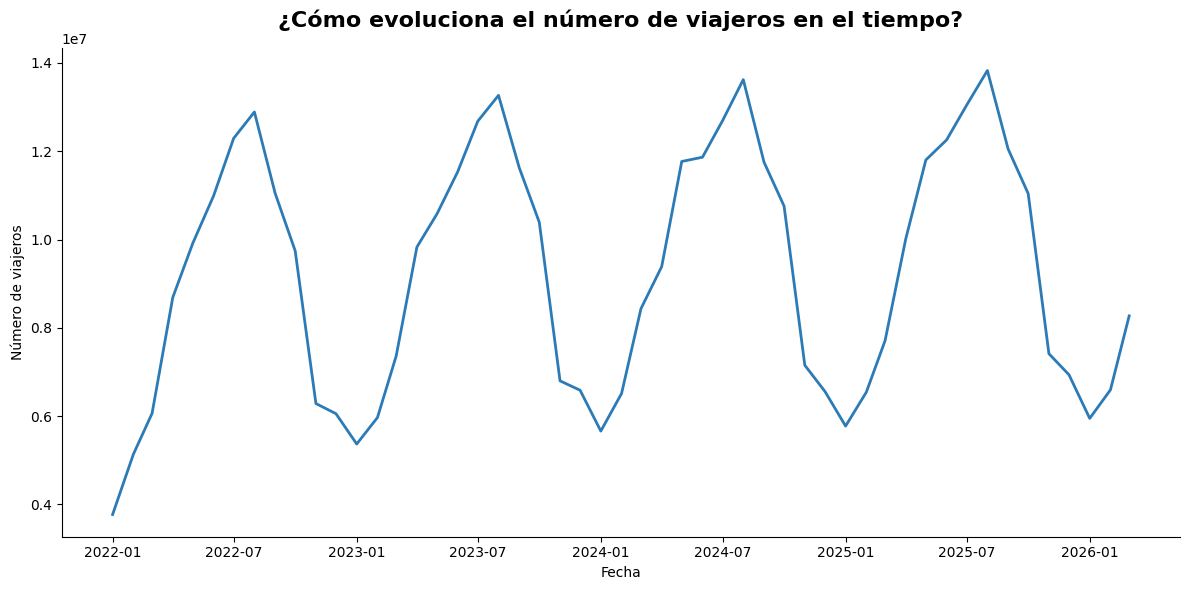

In [562]:
import matplotlib.pyplot as plt

# calculo el número de viajeros en el tiempo
viajeros_tiempo = (
    df_vp_ca
    .groupby("Fecha")["Viajeros"]
    .sum()
)

# creo el gráfico
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    viajeros_tiempo.index,
    viajeros_tiempo.values,
    color="#2C7BB6",
    linewidth=2
)

# titulo
ax.set_title(
    "¿Cómo evoluciona el número de viajeros en el tiempo?",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# nombres de los ejes
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")

# limpio el gráfico
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# elimino grid
ax.grid(False)

# fondo transparente
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()
plt.show()

ya vemos que hay seasonability

### ¿Cómo evoluciona el número de viajeros en el tiempo? (detalle año)

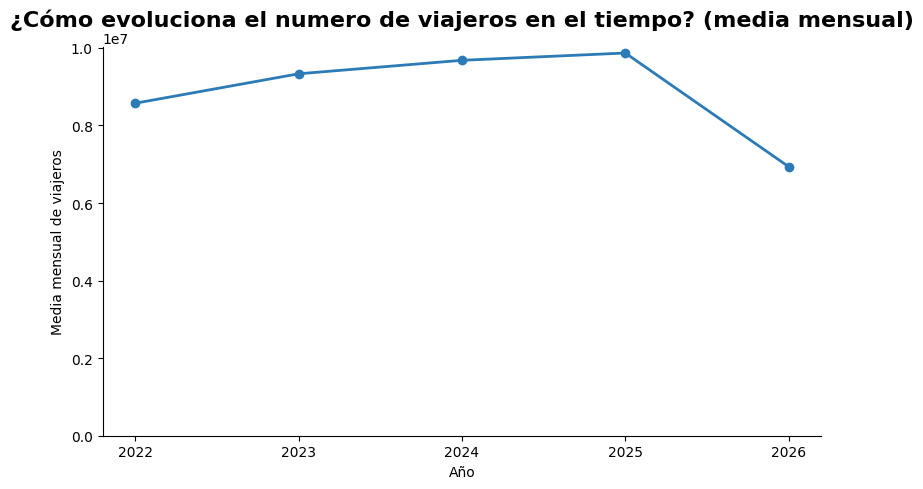

In [563]:
import matplotlib.pyplot as plt

# creo una copia con año y mes
df_vp_temp = df_vp_ca.copy()

df_vp_temp["Año"] = df_vp_temp["Fecha"].dt.year
df_vp_temp["Mes"] = df_vp_temp["Fecha"].dt.month

# calculo viajeros por mes
viajeros_mes = (
    df_vp_temp
    .groupby(["Año", "Mes"])["Viajeros"]
    .sum()
    .reset_index()
)

# calculo la media mensual de viajeros por año
viajeros_media_año = (
    viajeros_mes
    .groupby("Año")["Viajeros"]
    .mean()
)

# creo el gráfico
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    viajeros_media_año.index,
    viajeros_media_año.values,
    color="#2C7BB6",
    linewidth=2,
    marker="o"
)

# titulo
ax.set_title(
    "¿Cómo evoluciona el numero de viajeros en el tiempo? (media mensual)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# nombres de los ejes
ax.set_xlabel("Año")
ax.set_ylabel("Media mensual de viajeros")

# muestro correctamente los años
ax.set_xticks(viajeros_media_año.index)
ax.set_xticklabels(viajeros_media_año.index.astype(str))

# hago que el eje y empiece desde 0
ax.set_ylim(bottom=0)

# limpio gráfico
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

# fondo transparente
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()
plt.show()

### ¿Cómo evolucionan las pernoctaciones por viajero en el tiempo? (Detalle por mes)

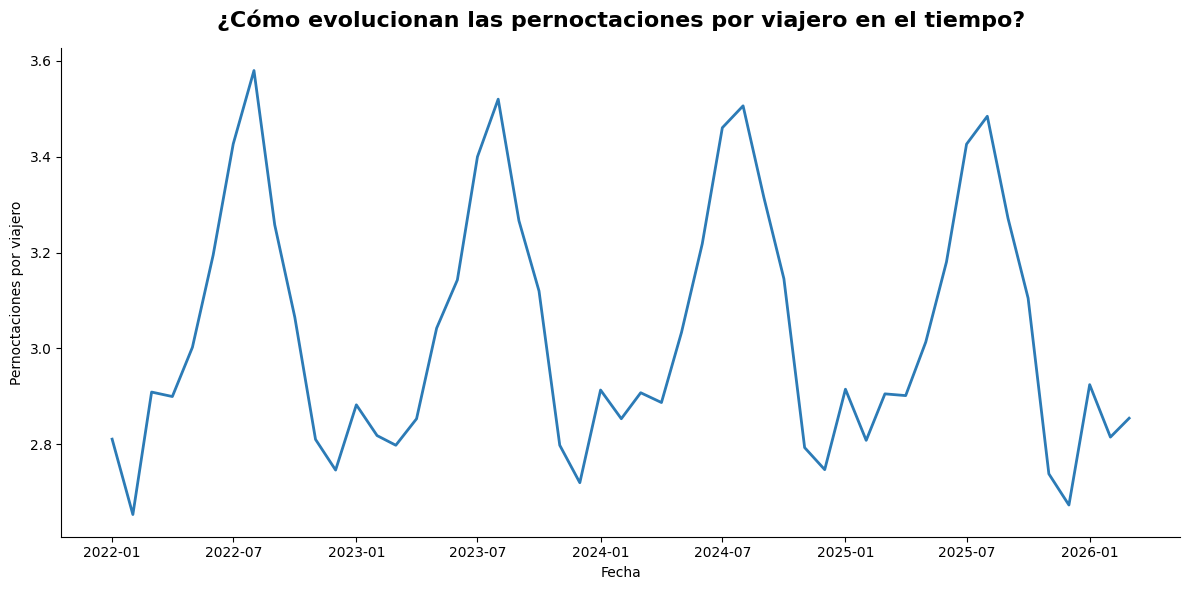

In [564]:
import matplotlib.pyplot as plt

# calculo pernoctaciones por viajero en el tiempo
pernoctaciones_viajero_tiempo = (
    df_vp_ca
    .groupby("Fecha")[["Pernoctaciones", "Viajeros"]]
    .sum()
)

pernoctaciones_viajero_tiempo["Pernoctaciones por viajero"] = (
    pernoctaciones_viajero_tiempo["Pernoctaciones"]
    / pernoctaciones_viajero_tiempo["Viajeros"]
)

# creo el gráfico
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(
    pernoctaciones_viajero_tiempo.index,
    pernoctaciones_viajero_tiempo["Pernoctaciones por viajero"],
    color="#2C7BB6",
    linewidth=2
)

# titulo
ax.set_title(
    "¿Cómo evolucionan las pernoctaciones por viajero en el tiempo?",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# nombres de los ejes
ax.set_xlabel("Fecha")
ax.set_ylabel("Pernoctaciones por viajero")

# limpio gráfico
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

# fondo transparente
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()
plt.show()

### ¿Cómo evolucionan las pernoctaciones por viajero en el tiempo? (Detalle por año)

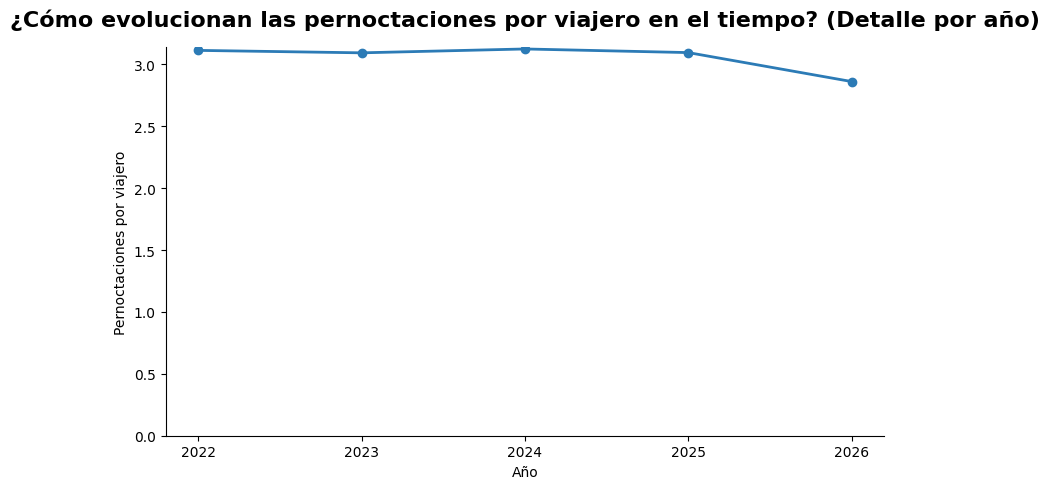

In [565]:
import matplotlib.pyplot as plt

# calculo pernoctaciones por viajero por año
pernoctaciones_viajero_año = (
    df_vp_ca
    .groupby(df_vp_ca["Fecha"].dt.year)[["Pernoctaciones", "Viajeros"]]
    .sum()
)

pernoctaciones_viajero_año["Pernoctaciones por viajero"] = (
    pernoctaciones_viajero_año["Pernoctaciones"]
    / pernoctaciones_viajero_año["Viajeros"]
)

# creo el gráfico
fig, ax = plt.subplots(figsize=(8,5))

ax.plot(
    pernoctaciones_viajero_año.index,
    pernoctaciones_viajero_año["Pernoctaciones por viajero"],
    color="#2C7BB6",
    linewidth=2,
    marker="o"
)

# titulo
ax.set_title(
    "¿Cómo evolucionan las pernoctaciones por viajero en el tiempo? (Detalle por año)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# nombres de los ejes
ax.set_xlabel("Año")
ax.set_ylabel("Pernoctaciones por viajero")

# muestro correctamente los años
ax.set_xticks(pernoctaciones_viajero_año.index)
ax.set_xticklabels(pernoctaciones_viajero_año.index.astype(str))

# hago que el eje y empiece desde 0
ax.set_ylim(bottom=0)

# limpio gráfico
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

# fondo transparente
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()
plt.show()

### ¿Cómo evolucionan viajeros y pernoctaciones en el tiempo?

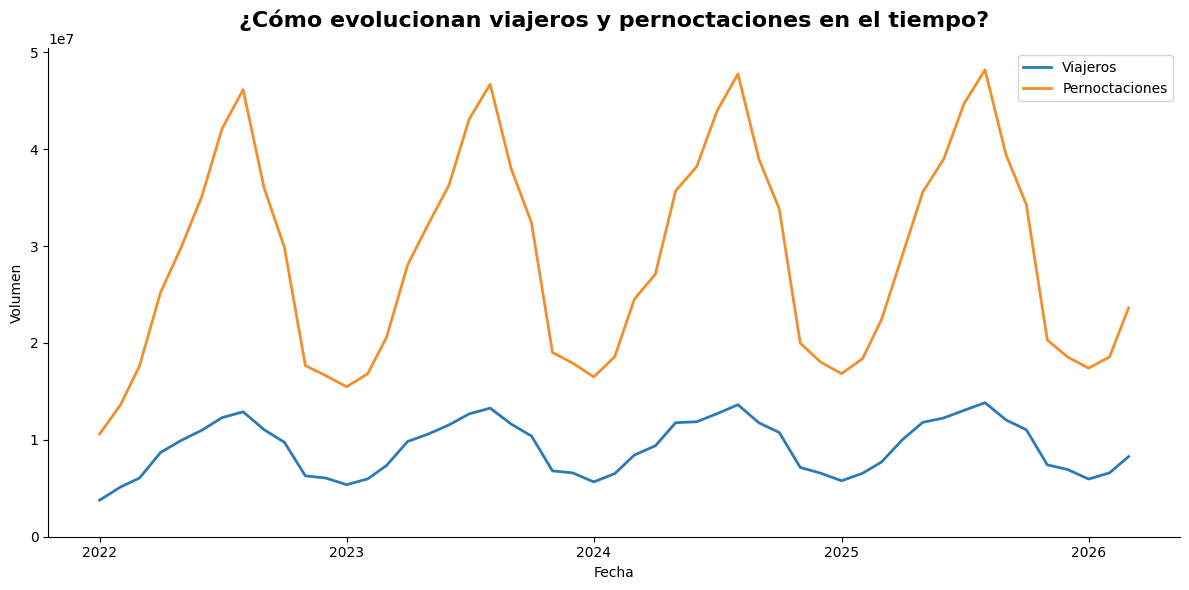

In [566]:
import matplotlib.pyplot as plt

# calculo viajeros y pernoctaciones en el tiempo
evolucion_tiempo = (
    df_vp_ca
    .groupby("Fecha")[["Viajeros", "Pernoctaciones"]]
    .sum()
)

# creo el gráfico
fig, ax = plt.subplots(figsize=(12,6))

# línea viajeros
ax.plot(
    evolucion_tiempo.index,
    evolucion_tiempo["Viajeros"],
    label="Viajeros",
    color="#2C7BB6",
    linewidth=2
)

# línea pernoctaciones
ax.plot(
    evolucion_tiempo.index,
    evolucion_tiempo["Pernoctaciones"],
    label="Pernoctaciones",
    color="#F28E2B",
    linewidth=2
)

# titulo
ax.set_title(
    "¿Cómo evolucionan viajeros y pernoctaciones en el tiempo?",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# nombres de los ejes
ax.set_xlabel("Fecha")
ax.set_ylabel("Volumen")

# muestro los años correctamente
años = evolucion_tiempo.index.year.unique()
ax.set_xticks(
    [evolucion_tiempo[evolucion_tiempo.index.year == año].index[0] for año in años]
)
ax.set_xticklabels(años.astype(str))

# hago que el eje y empiece desde 0
ax.set_ylim(bottom=0)

# leyenda
ax.legend()

# limpio el gráfico
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# elimino grid
ax.grid(False)

# fondo transparente
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.tight_layout()
plt.show()

### ¿Cómo evolucionan los viajeros y las pernoctaciones por viajero en el tiempo?

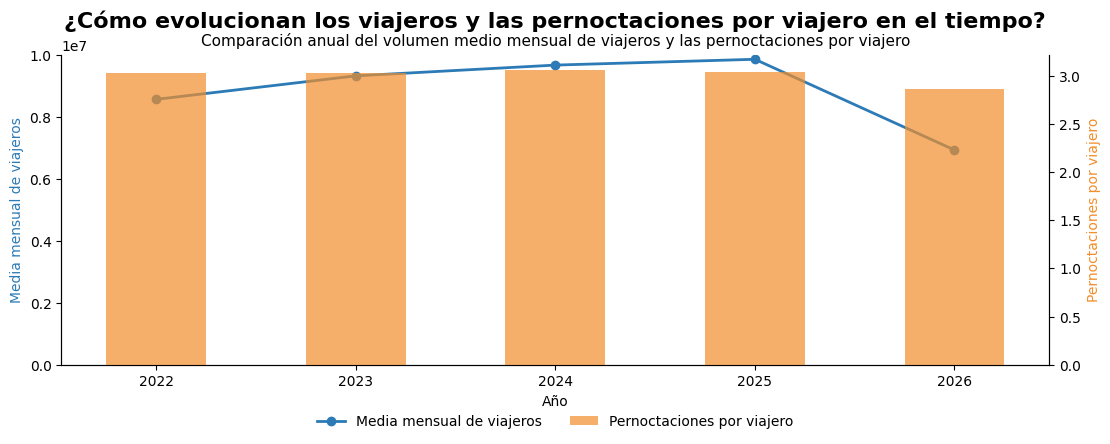

In [567]:
import matplotlib.pyplot as plt

# creo una copia con año y mes
df_vp_temp = df_vp_ca.copy()

df_vp_temp["Año"] = df_vp_temp["Fecha"].dt.year
df_vp_temp["Mes"] = df_vp_temp["Fecha"].dt.month

# calculo viajeros y pernoctaciones por mes
evolucion_mes = (
    df_vp_temp
    .groupby(["Año", "Mes"])[["Viajeros", "Pernoctaciones"]]
    .sum()
    .reset_index()
)

# calculo pernoctaciones por viajero por mes
evolucion_mes["Pernoctaciones por viajero"] = (
    evolucion_mes["Pernoctaciones"]
    / evolucion_mes["Viajeros"]
)

# calculo la media mensual por año
evolucion_año = (
    evolucion_mes
    .groupby("Año")[["Viajeros", "Pernoctaciones por viajero"]]
    .mean()
)

# creo figura
fig, ax1 = plt.subplots(figsize=(13,5))

# eje principal → media mensual de viajeros
ax1.plot(
    evolucion_año.index,
    evolucion_año["Viajeros"],
    color="#2C7BB6",
    linewidth=2,
    marker="o",
    label="Media mensual de viajeros"
)

ax1.set_xlabel("Año")
ax1.set_ylabel("Media mensual de viajeros", color="#2C7BB6")

ax1.set_xticks(evolucion_año.index)
ax1.set_xticklabels(evolucion_año.index.astype(str))

ax1.set_ylim(bottom=0)

# segundo eje → media de pernoctaciones por viajero
ax2 = ax1.twinx()

ax2.bar(
    evolucion_año.index,
    evolucion_año["Pernoctaciones por viajero"],
    color="#F28E2B",
    alpha=0.7,
    width=0.5,
    label="Pernoctaciones por viajero"
)

ax2.set_ylabel("Pernoctaciones por viajero", color="#F28E2B")

# titulo
ax1.set_title(
    "¿Cómo evolucionan los viajeros y las pernoctaciones por viajero en el tiempo?",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# subtitulo
ax1.text(
    0.5,
    1.03,
    "Comparación anual del volumen medio mensual de viajeros y las pernoctaciones por viajero",
    transform=ax1.transAxes,
    ha="center",
    fontsize=11
)

# limpio gráfico
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

ax1.grid(False)
ax2.grid(False)

# fondo transparente
fig.patch.set_alpha(0)
ax1.set_facecolor("none")

# leyenda combinada
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines_1 + lines_2,
    labels_1 + labels_2,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=2,
    frameon=False
)

# ajusto márgenes manualmente
fig.subplots_adjust(
    left=0.12,
    right=0.88,
    top=0.82,
    bottom=0.2
)

plt.show()

### Estacionalidad: Cómo cambia la estancia media según el mes del año?

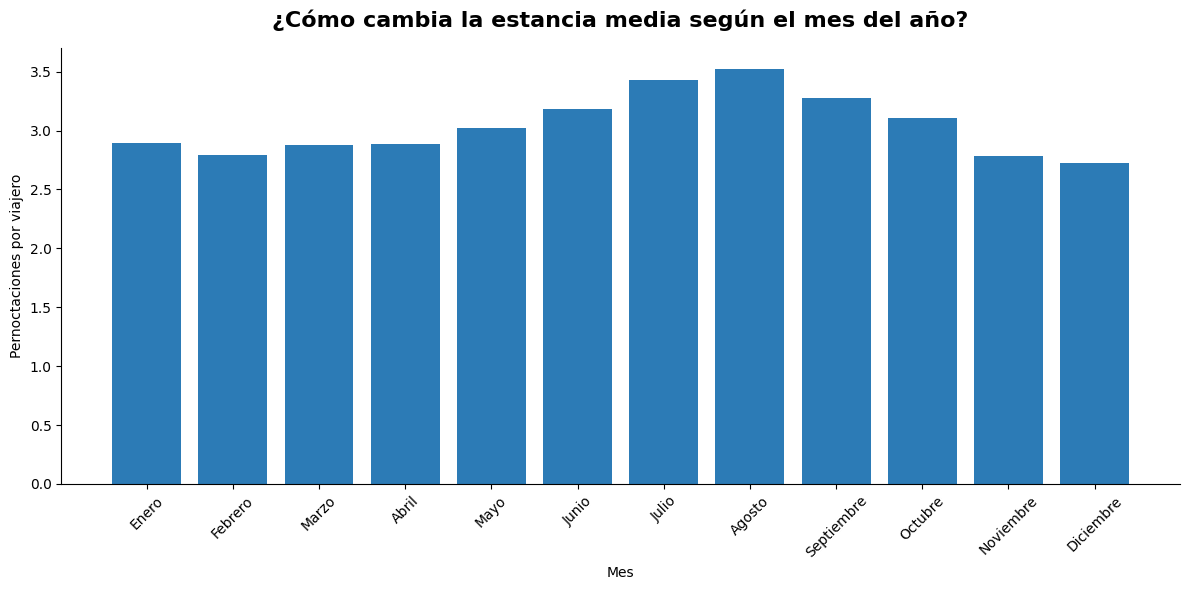

In [568]:
import matplotlib.pyplot as plt

# calculo pernoctaciones por viajero agrupando todos los meses iguales
estacionalidad = (
    df_vp_ca
    .groupby(["Mes", "Nombre mes"])[["Pernoctaciones", "Viajeros"]]
    .sum()
    .reset_index()
)

# calculo pernoctaciones por viajero
estacionalidad["Pernoctaciones por viajero"] = (
    estacionalidad["Pernoctaciones"]
    / estacionalidad["Viajeros"]
)

# ordeno por número de mes
estacionalidad = estacionalidad.sort_values("Mes")

# creo el gráfico
fig, ax = plt.subplots(figsize=(12,6))

ax.bar(
    estacionalidad["Nombre mes"],
    estacionalidad["Pernoctaciones por viajero"],
    color="#2C7BB6"
)

# titulo
ax.set_title(
    "¿Cómo cambia la estancia media según el mes del año?",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# nombres de los ejes
ax.set_xlabel("Mes")
ax.set_ylabel("Pernoctaciones por viajero")

# hago que el eje y empiece desde 0
ax.set_ylim(bottom=0)

# limpio gráfico
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

# fondo transparente
fig.patch.set_alpha(0)
ax.set_facecolor("none")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### ¿qué porcentaje de viajeros procede de españa y del extranjero?

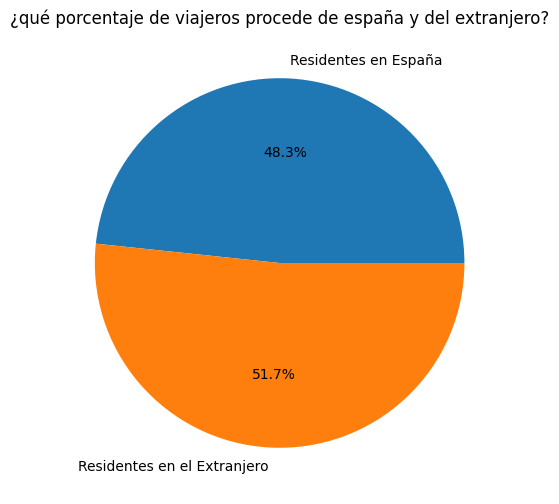

In [569]:
# viajeros por residencia en porcentaje

viajeros_residencia_pct = (
    df_vp_ca
    .groupby("Residencia")["Viajeros"]
    .sum()
    / df_vp_ca["Viajeros"].sum()
    * 100
).round(2)

# grafico a torta

plt.figure(figsize=(6,6))

plt.pie(
    viajeros_residencia_pct,
    labels=viajeros_residencia_pct.index,
    autopct='%1.1f%%'
)

plt.title("¿qué porcentaje de viajeros procede de españa y del extranjero?")

plt.show()

### ¿cuántas pernoctaciones corresponden a viajeros nacionales y extranjeros?

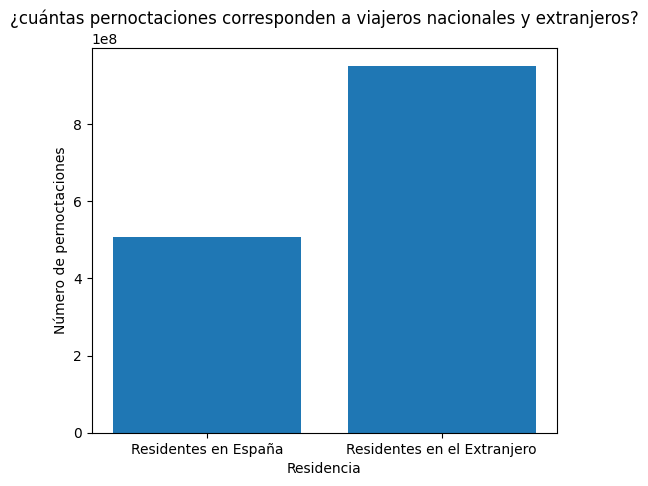

In [570]:
# pernoctaciones por residencia en numero absoluto

pernoctaciones_residencia = (
    df_vp_ca
    .groupby("Residencia")["Pernoctaciones"]
    .sum()
)

# grafico a columnas

plt.figure(figsize=(6,5))

plt.bar(
    pernoctaciones_residencia.index,
    pernoctaciones_residencia.values
)

plt.title("¿cuántas pernoctaciones corresponden a viajeros nacionales y extranjeros?")
plt.xlabel("Residencia")
plt.ylabel("Número de pernoctaciones")

plt.show()

#### Qué comunidades tienen la estancia media más alta?

Tabla

In [574]:
# Estancia media promedio por comunidad
estancia_ccaa = (
    df_e_ca
    .groupby("Comunidad")["Estancia media"]
    .mean()
    .sort_values(ascending=False)
)

estancia_ccaa

Comunidad
Canarias                       6.511765
Balears, Illes                 4.413922
Comunitat Valenciana           3.052157
Andalucía                      2.666863
Cataluña                       2.614510
Melilla                        2.255294
Murcia, Región de              2.219216
Ceuta                          2.072745
Cantabria                      2.057647
Madrid, Comunidad de           2.024706
Aragón                         1.977255
Asturias, Principado de        1.975490
País Vasco                     1.939608
Navarra, Comunidad Foral de    1.858039
Galicia                        1.854706
Extremadura                    1.776471
Castilla - La Mancha           1.750980
Rioja, La                      1.733529
Castilla y León                1.690784
Name: Estancia media, dtype: float64

Visualizacion

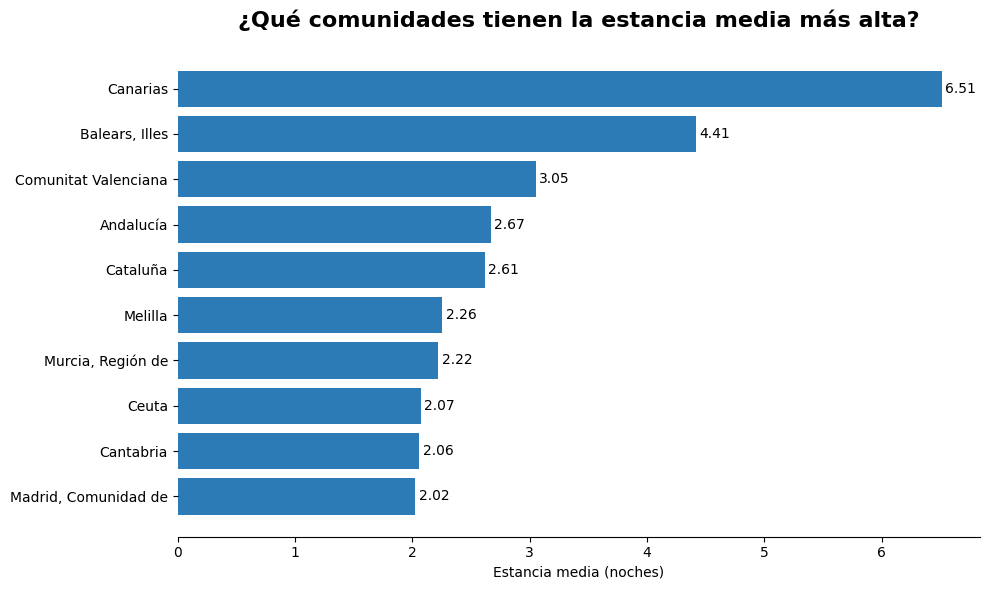

In [575]:
import matplotlib.pyplot as plt

# =========================
# ORDENAR DATOS
# =========================

# Top 10 comunidades con estancia media más alta
estancia_ccaa_top10 = (
    estancia_ccaa
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

# =========================
# GRAFICO
# =========================

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    estancia_ccaa_top10.index,
    estancia_ccaa_top10.values,
    color="#2C7BB6"
)

# =========================
# TITULO Y EJE X
# =========================

ax.set_title(
    "¿Qué comunidades tienen la estancia media más alta?",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Estancia media (noches)")
ax.set_ylabel("")

# =========================
# LIMPIEZA VISUAL
# =========================

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Elimina completamente la grid
ax.grid(False)

# Fondo transparente
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# =========================
# ETIQUETAS
# =========================

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

____________________________